In [2]:
pip install umap-learn

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


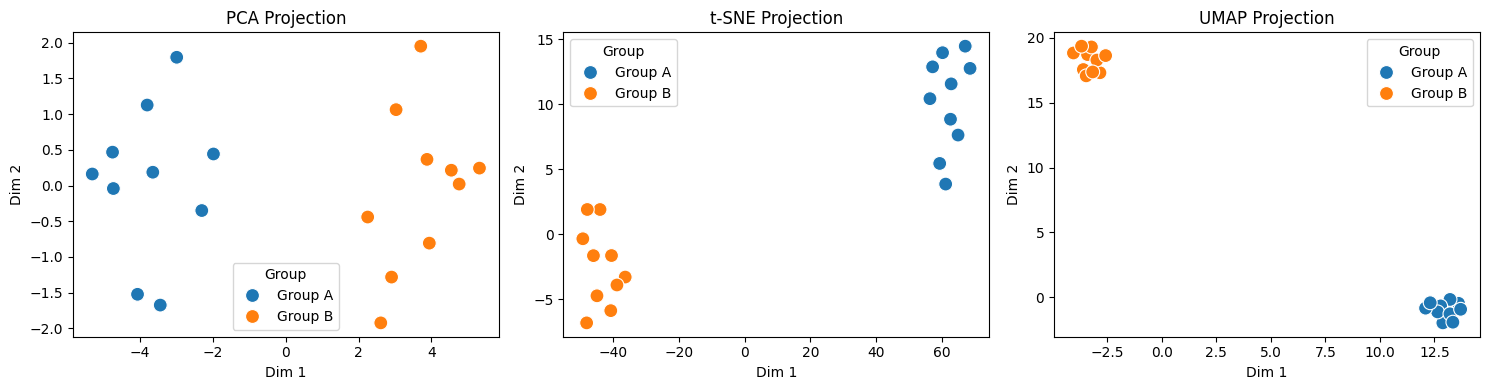

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap


np.random.seed(42)

data = np.random.randn(20, 4)

# Create two groups
data[10:, :] += 3.5

labels = ['Group A'] * 10 + ['Group B'] * 10


# Convert data into DataFrame
df = pd.DataFrame(
    data,
    columns=['F1', 'F2', 'F3', 'F4']
)


# PCA
pca = PCA(n_components=2)

pca_result = pca.fit_transform(df)


# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=5,
    random_state=42
)

tsne_result = tsne.fit_transform(df)


# UMAP
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=5,
    random_state=42
)

umap_result = umap_model.fit_transform(df)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)


results = [
    ('PCA', pca_result),
    ('t-SNE', tsne_result),
    ('UMAP', umap_result)
]


for ax, (title, result) in zip(axes, results):

    plot_df = pd.DataFrame(
        result,
        columns=['Dim 1', 'Dim 2']
    )

    plot_df['Group'] = labels

    sns.scatterplot(
        data=plot_df,
        x='Dim 1',
        y='Dim 2',
        hue='Group',
        ax=ax,
        s=100
    )

    ax.set_title(title + ' Projection')


plt.tight_layout()
plt.show()